# Rust LogisticRegression vs sklearn — grid benchmark

Sweeps a grid of dataset shapes and records, per shape:

- **fit time** and **predict time** for both estimators (best-of N repeats)
- **accuracy** on a held-out split
- **agreement** between the two models' predictions
- **relative L2 difference** of the learned coefficients

Both estimators use `fit_intercept=False` (our adapter requires it) so the
comparison is apples-to-apples. We sweep rows and cols **gradually** so it is
easy to see at which shape (if any) behaviour diverges.

# New Benachmark

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root

In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from adapters.LogisticRegression import LogisticRegression as RustLogisticRegression
import timeit

_ROWS = [
    100,
    1000,
    10000,
    100_000,
    500_000,
    1_000_000,
    5_000_000
]

_COLUMNS = [
    10,
    100,
    1_000,
    10_000,
    100_000,
    500_000,
]

_MAX_ITERS = [10, 100, 500, 1_000, 5_000, 10_000]



In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

In [3]:
def plot_benchmark_data(title, xlabel, ylabel, x, y_rust, y_sklearn):
    width = 0.4
    x_pos = np.arange(len(x))

    plt.figure(figsize=(10, 6))
    plt.bar(x_pos - width/2, y_rust, width, label="Rust")
    plt.bar(x_pos + width/2, y_sklearn, width, label="Scikit-Learn")

    plt.xticks(x_pos, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
df = pd.read_csv("/home/bl4ck_r4bbit/Schreibtisch/TUBerlin/MLMMI-Project/rust_experiments/benchmarks/results/col_row_iter.csv")
df.drop(columns=["max_iters", "kernel", "repeats"], inplace=True)
df

,rows,cols,fit_time,fit_std,predict_time,predict_std,acc,fit_rust_speedup,predict_rust_speedup
0,100,10,"[0.0007996819999789295, 0.0037981132504683046]","[0.00023506192750121969, 0.0005507498220489722]","[3.9065750115696574e-05, 0.00017384675038556452]","[9.616495837990186e-06, 1.1187927458305652e-05]","[np.float64(0.8), np.float64(0.86)]",4.749530,4.450107
1,100,50,"[0.008200858249892917, 0.028264560499792424]","[0.0007251024868935634, 0.0024076488183263096]","[3.323999999338412e-05, 0.00018251875007990748]","[3.0744336411657852e-06, 1.1033570219209183e-05]","[np.float64(0.95), np.float64(0.98)]",3.446537,5.490937
2,100,100,"[0.011857406750095834, 0.0142426115003218]","[0.0016103850822256965, 0.00022164877428815393]","[3.894500014212099e-05, 0.00012010425052721985]","[7.734496770989137e-06, 1.793399960219465e-05]","[np.float64(1.0), np.float64(1.0)]",1.201157,3.083945
3,100,500,"[0.004126584500227182, 0.004909146250611229]","[0.0014319448218957094, 0.00029429668011103134]","[4.980750054528471e-05, 0.0001393935003761726]","[6.553896429400136e-06, 7.563757705012605e-06]","[np.float64(1.0), np.float64(1.0)]",1.189639,2.798645
4,100,1000,"[0.0048600422501294815, 0.004534579999472044]","[0.00028218652178320933, 0.0003145589068417846]","[9.22474996514211e-05, 0.00013496300016413443]","[3.7291965587945197e-06, 1.6395605565343135e-05]","[np.float64(1.0), np.float64(1.0)]",0.933033,1.463053
5,500,10,"[0.0013841465001860342, 0.0025115400003414834]","[3.935606769801218e-05, 0.0009721370065903311]","[4.1475249872746645e-05, 0.0001456687500649423]","[1.2720520797048297e-05, 2.34230173140681e-05]","[np.float64(0.774), np.float64(0.85)]",1.814504,3.512185
6,500,50,"[0.008719858999938879, 0.007085644499966293]","[0.0008788085352047851, 0.00030305373378245956]","[7.504724999307655e-05, 0.00010215250040346291]","[1.3553465297503146e-05, 1.2962291243859982e-05]","[np.float64(0.838), np.float64(0.828)]",0.812587,1.361176
7,500,100,"[0.0203564237503997, 0.015305552999961947]","[0.005466087751676625, 0.0015573448177979437]","[6.189599935169099e-05, 0.00011170650031999685]","[1.0177331883615384e-05, 1.609814321541039e-05]","[np.float64(0.868), np.float64(0.87)]",0.751878,1.804745
8,500,500,"[0.059092369000154576, 0.0775340922500618]","[0.006069108287407555, 0.0025276362211775123]","[0.00013986975000079838, 0.00022117549997346941]","[1.5688346866766385e-05, 2.4560990326386298e-05]","[np.float64(1.0), np.float64(1.0)]",1.312083,1.581296
9,500,1000,"[0.04491296049945959, 1.9045151057498515]","[0.00162174807594398, 0.12988712412070091]","[0.00022259249999478925, 0.0029949812496852246]","[1.5810488824602814e-05, 6.154998734441524e-06]","[np.float64(1.0), np.float64(1.0)]",42.404577,13.454996


In [20]:
def plot_for_fixed_cols(columns: int, df: pd.DataFrame):
    df = df.loc[df["cols"] == columns, :]
    df.drop(columns=["cols"], inplace=True)

    rows = df["rows"].to_numpy()
    fit_time = np.array(df["fit_time"].map(lambda x: [float(val) for val in x[1:-1].split(",")]).tolist(), dtype="float64")
    predict_time = np.array(df["predict_time"].map(lambda x: [float(val) for val in x[1:-1].split(",")]).tolist(), dtype="float64")
    accuracies = np.array(df["acc"].map(lambda x : [float(val[len("np.float64("):-1]) for val in x[1:-1].split(", ")]).tolist(), dtype="float64")

    plot_benchmark_data(
        title=f"Fit Time for {columns} Columns",
        xlabel="Rows",
        ylabel="Time (seconds)",
        x=rows,
        y_rust=fit_time[:, 0],
        y_sklearn=fit_time[:, 1]
    )

    plot_benchmark_data(
        title=f"Predict Time for {columns} Columns",
        xlabel="Rows",
        ylabel="Time (seconds)",
        x=rows,
        y_rust=predict_time[:, 0],
        y_sklearn=predict_time[:, 1]
    )

    plot_benchmark_data(
        title=f"Accuracy comparison",
        xlabel="Rows",
        ylabel="Accuracy in [0,1]",
        x=rows,
        y_rust=accuracies[:, 0],
        y_sklearn=accuracies[:, 1]
    )


def plot_for_fixed_rows(rows: int, df: pd.DataFrame):
    df = df.loc[df["rows"] == rows, :]
    df.drop(columns=["rows"], inplace=True)

    cols = df["cols"].to_numpy()
    fit_time = np.array(df["fit_time"].map(lambda x: [float(val) for val in x[1:-1].split(",")]).tolist(), dtype="float64")
    predict_time = np.array(df["predict_time"].map(lambda x: [float(val) for val in x[1:-1].split(",")]).tolist(), dtype="float64")
    accuracies = np.array(df["acc"].map(lambda x : [float(val[len("np.float64("):-1]) for val in x[1:-1].split(", ")]).tolist(), dtype="float64")

    plot_benchmark_data(
        title=f"Fit Time for {rows} Rows",
        xlabel="Columns",
        ylabel="Time (seconds)",
        x=cols,
        y_rust=fit_time[:, 0],
        y_sklearn=fit_time[:, 1]
    )

    plot_benchmark_data(
        title=f"Predict Time for {rows} Rows",
        xlabel="Columns",
        ylabel="Time (seconds)",
        x=cols,
        y_rust=predict_time[:, 0],
        y_sklearn=predict_time[:, 1]
    )

    plot_benchmark_data(
        title=f"Accuracy comparison",
        xlabel="Columns",
        ylabel="Accuracy in [0,1]",
        x=cols,
        y_rust=accuracies[:, 0],
        y_sklearn=accuracies[:, 1]
    )


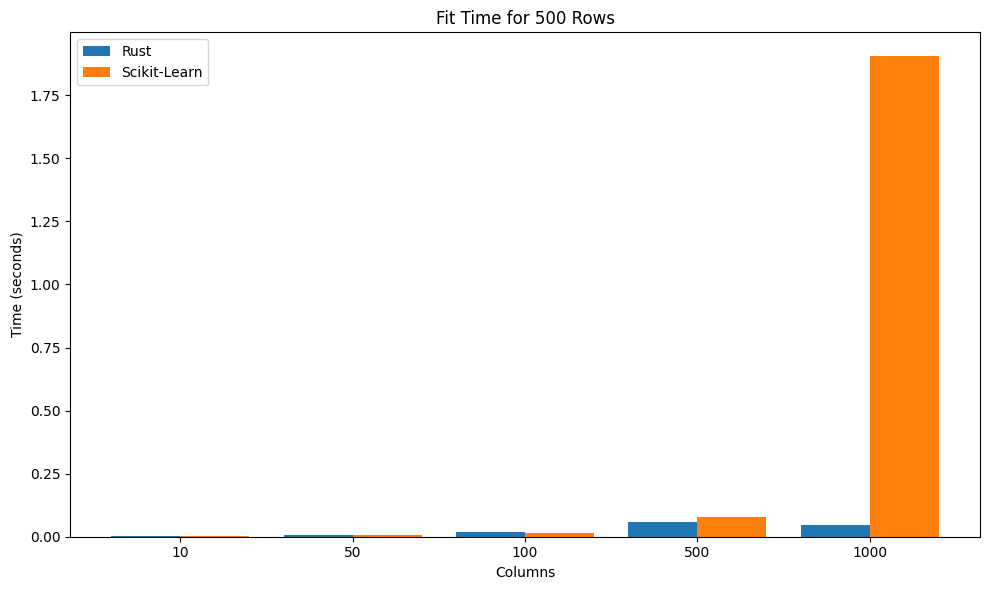

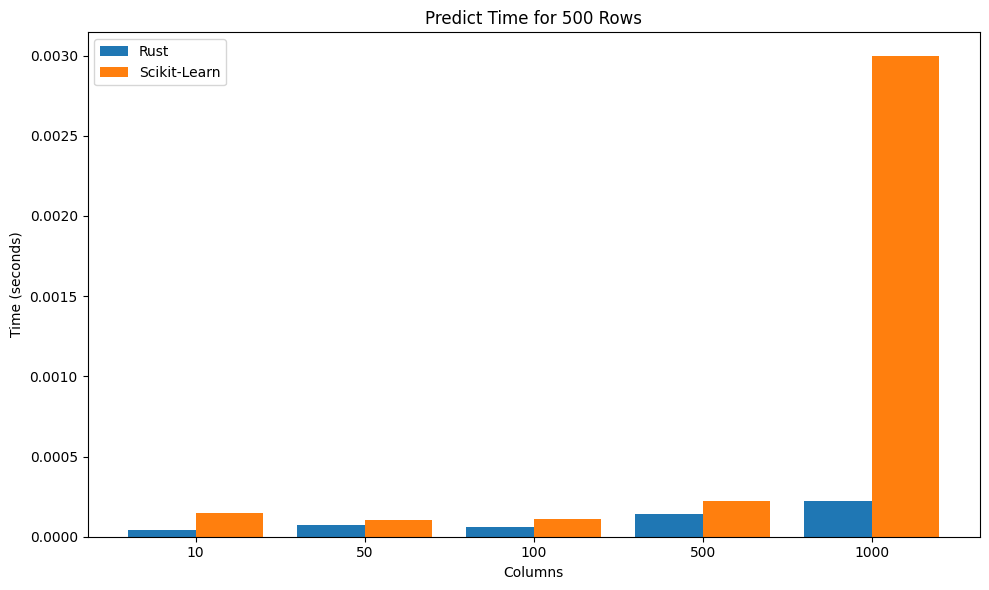

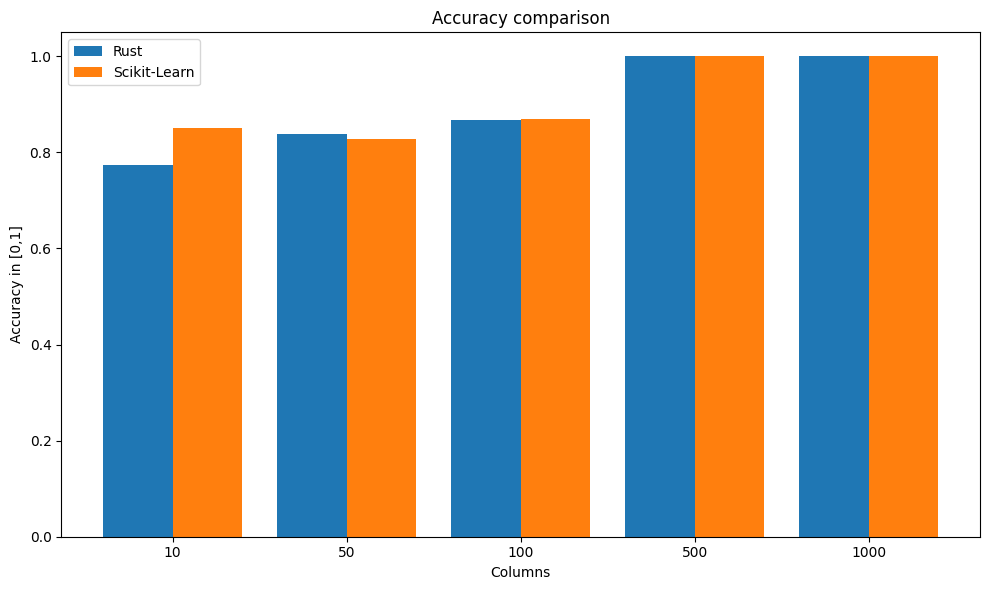

In [24]:
plot_for_fixed_rows(500, df)